# Active Learning Project - OPTIMIZED (CPU ~2-3h)

## Configuration Optimized for Time
- Budgets: 1%, 2%, 10%, 20%, 50% (removed 5%)
- Runs: 2 (was 3)
- Epochs: 2 (was 3)
- TTA/Ensemble passes: 3 each (was 5)
- **Total: 4 strategies × 5 budgets × 2 runs = 40 iterations (~2-3h)**

In [22]:
import os, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import cv2, time
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Paths
active_learning_dir = r'C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning'
dataset_dir = os.path.join(active_learning_dir, 'Dataset')
testset_dir = os.path.join(active_learning_dir, 'testSet1')

# Load data
dataset_sc1 = pd.read_csv(os.path.join(dataset_dir, 'coords_SC1.csv'))
dataset_yas = pd.read_csv(os.path.join(dataset_dir, 'Coords_Yas1.csv'))
testset_db = pd.read_csv(os.path.join(testset_dir, 'coords_SC-test.csv'))

dataset_sc1['source'] = 'SC1'
dataset_yas['source'] = 'YAS1'
dataset_db = pd.concat([dataset_sc1, dataset_yas], ignore_index=True)

print(f"Dataset: {len(dataset_db)} (SC1: {len(dataset_sc1)}, YAS1: {len(dataset_yas)})")
print(f"Test: {len(testset_db)}")

Device: cpu
Dataset: 10716 (SC1: 7149, YAS1: 3567)
Test: 3569


In [23]:
# Debug columns
print("Columns in dataset_db:", dataset_db.columns.tolist())

Columns in dataset_db: ['frame_id', 'timestamp', 'x', 'y', 'source']


In [24]:
# Check label scale
print("x stats:", dataset_db['x'].min(), dataset_db['x'].max(), dataset_db['x'].mean())
print("y stats:", dataset_db['y'].min(), dataset_db['y'].max(), dataset_db['y'].mean())
print("head:\n", dataset_db[['x','y']].head())

x stats: -4 1604 800.4442889137738
y stats: 5 897 448.9056550951848
head:
       x    y
0  1524  295
1  1544  299
2  1563  303
3  1583  307
4  1603  311


In [25]:
# Model selection based on checkpoint shapes
IMAGE_SIZE = 224  # default

class GazeNetLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
        self.fc1 = nn.Linear(64 * 56 * 56, 512)
        self.fc2 = nn.Linear(512, 2)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))

class GazeNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 2)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))  # single pooling to get 14x14 if input is 28x28
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))

class DomainBDataset(Dataset):
    def __init__(self, df, base_path):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        # Normalization stats for labels
        self.max_x = self.df['x'].max()
        self.max_y = self.df['y'].max()
        self.min_x = self.df['x'].min()
        self.min_y = self.df['y'].min()
        # Detect if already normalized
        self.is_normalized = (0.0 <= self.min_x <= 1.0 and 0.0 <= self.min_y <= 1.0 and
                              0.0 <= self.max_x <= 1.0 and 0.0 <= self.max_y <= 1.0)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        source = row.get('source', 'SC1')
        frame_id = int(row['frame_id'])
        
        if source == 'YAS1':
            img_name = f"SCtes_t_{frame_id:04d}.png"
            img_dir = os.path.join(self.base_path, 'frameYas1')
        else:
            img_name = f"SC1_{frame_id:04d}.png"
            img_dir = os.path.join(self.base_path, 'dataStev', 'framesSC1')
        
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        
        x_val = float(row['x'])
        y_val = float(row['y'])
        if not self.is_normalized and self.max_x > 0 and self.max_y > 0:
            x_val = x_val / self.max_x
            y_val = y_val / self.max_y
        label = np.array([x_val, y_val], dtype=np.float32)
        return torch.from_numpy(img), torch.from_numpy(label)

def evaluate_model(model, loader, device):
    model.eval()
    mae, mse = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            mae += torch.abs(outputs - labels).mean(dim=1).sum().item()
            mse += ((outputs - labels) ** 2).mean(dim=1).sum().item()
    n = len(loader.dataset)
    return {'mae': mae/n, 'mse': mse/n, 'rmse': np.sqrt(mse/n)}

# Load model (data/gaze_model_trained.pth)
checkpoint_path = os.path.join(active_learning_dir, 'data', 'gaze_model_trained.pth')
raw = torch.load(checkpoint_path, map_location=device)
state = raw['state_dict'] if isinstance(raw, dict) and 'state_dict' in raw else raw

# Detect architecture
conv1_w = state['conv1.weight']
fc1_w = state['fc1.weight']

use_small = (conv1_w.shape == torch.Size([16, 3, 3, 3]) and fc1_w.shape[1] == 6272)

if use_small:
    IMAGE_SIZE = 28
    ModelClass = GazeNetSmall
    baseline_model = ModelClass().to(device)
    model_name = 'GazeNetSmall (28x28 input)'
else:
    IMAGE_SIZE = 224
    ModelClass = GazeNetLarge
    baseline_model = ModelClass().to(device)
    model_name = 'GazeNetLarge (224x224 input)'

baseline_model.load_state_dict(state)

print(f"Model loaded: {checkpoint_path}")
print(f"Architecture: {model_name}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Params: {sum(p.numel() for p in baseline_model.parameters()):,}")

Model loaded: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\data\gaze_model_trained.pth
Architecture: GazeNetSmall (28x28 input)
Image size: 28x28
Params: 1,611,490


In [26]:
# Split: 10% baseline, 90% AL pool
split_ratio = 0.1
idx = np.random.RandomState(42).permutation(len(dataset_db))
baseline_train_db = dataset_db.iloc[idx[:int(len(dataset_db)*split_ratio)]].reset_index(drop=True)
al_pool_db = dataset_db.iloc[idx[int(len(dataset_db)*split_ratio):]].reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Baseline train: {len(baseline_train_db)} (10%)")
print(f"AL pool: {len(al_pool_db)} (90%)")
print(f"Test: {len(testset_db)}")
print(f"{'='*60}")


Baseline train: 1071 (10%)
AL pool: 9645 (90%)
Test: 3569


In [27]:
# Train baseline
print("\nTraining baseline...")
start = time.time()

train_loader = DataLoader(DomainBDataset(baseline_train_db, dataset_dir), batch_size=32, shuffle=True)
test_loader = DataLoader(DomainBDataset(testset_db, dataset_dir), batch_size=32, shuffle=False)

criterion = nn.MSELoss()
opt = optim.Adam(baseline_model.parameters(), lr=1e-4)

baseline_model.train()
for epoch in range(5):
    loss_sum = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        opt.zero_grad()
        loss = criterion(baseline_model(img), lbl)
        loss.backward()
        opt.step()
        loss_sum += loss.item()
    print(f"  Epoch {epoch+1}/5: {loss_sum/len(train_loader):.6f}")

baseline_metrics = evaluate_model(baseline_model, test_loader, device)
print(f"✓ Baseline: MAE={baseline_metrics['mae']:.6f}, time={time.time()-start:.1f}s")

baseline_state = baseline_model.state_dict()


Training baseline...
  Epoch 1/5: 0.083270
  Epoch 2/5: 0.081973
  Epoch 3/5: 0.081606
  Epoch 4/5: 0.081575
  Epoch 5/5: 0.081281
✓ Baseline: MAE=0.251031, time=69.7s


In [28]:
class AL:
    def uncertainty_tta(self, m, l, d, n=3):
        """TTA variance = uncertainty"""
        m.eval()
        unc = []
        with torch.no_grad():
            for img, _ in l:
                img = img.to(d)
                p = []
                for _ in range(n):
                    if torch.rand(1) > 0.5:
                        img_aug = torch.flip(img, dims=[3])
                    else:
                        img_aug = img
                    p.append(m(img_aug).cpu().numpy())
                p = np.array(p)
                unc.extend(np.var(p, axis=0).mean(axis=1))
        return np.array(unc)
    
    def diversity_kmeans(self, m, l, d, n_c):
        """K-means for diversity"""
        m.eval()
        feat = []
        with torch.no_grad():
            for img, _ in l:
                img = img.to(d)
                x = m.pool(F.relu(m.conv1(img)))
                x = m.pool(F.relu(m.conv2(x)))
                x = x.view(x.size(0), -1)
                feat.append(x.cpu().numpy())
        feat = np.concatenate(feat)
        if feat.shape[1] > 50:
            pca = PCA(50)
            feat = pca.fit_transform(feat)
        km = KMeans(min(n_c, len(feat)), random_state=42)
        km.fit(feat)
        sel = []
        for i in range(km.n_clusters):
            idx = np.where(km.labels_==i)[0]
            if len(idx) > 0:
                d_to_c = np.linalg.norm(feat[idx] - km.cluster_centers_[i], axis=1)
                sel.append(idx[np.argmin(d_to_c)])
        return np.array(sel)
    
    def mixed_ud(self, m, l, d, a=0.6):
        """U + D mixed"""
        u = self.uncertainty_tta(m, l, d, n=3)
        u = (u - u.min()) / (u.max() - u.min() + 1e-8)
        m.eval()
        feat = []
        with torch.no_grad():
            for img, _ in l:
                img = img.to(d)
                x = m.pool(F.relu(m.conv1(img)))
                x = m.pool(F.relu(m.conv2(x)))
                x = x.view(x.size(0), -1)
                feat.append(x.cpu().numpy())
        feat = np.concatenate(feat)
        dist = cdist(feat, feat)
        div = np.mean(dist, axis=1)
        div = (div - div.min()) / (div.max() - div.min() + 1e-8)
        return a * u + (1-a) * div
    
    def ensemble(self, m, l, d, n=3):
        """Ensemble voting"""
        m.eval()
        ens = []
        with torch.no_grad():
            for img, _ in l:
                img = img.to(d)
                b = []
                for _ in range(n):
                    m.train()
                    b.append(m(img).cpu().numpy())
                ens.append(b)
        m.eval()
        all_p = []
        for b in ens:
            b = np.array(b)
            all_p.extend(np.var(b, axis=0).mean(axis=1))
        return np.array(all_p)

print("✓ AL strategies ready")

✓ AL strategies ready


In [29]:
# RUN EXPERIMENT
al = AL()
pool_loader = DataLoader(DomainBDataset(al_pool_db, dataset_dir), batch_size=32, shuffle=False)

strategies = ['random', 'uncertainty_tta', 'diversity_kmeans', 'mixed_ud', 'ensemble']
results = {s: {b: [] for b in budgets} for s in strategies}

for run in range(n_runs):
    print(f"\n{'='*80}")
    print(f"RUN {run+1}/{n_runs}")
    print('='*80)
    
    np.random.seed(100 + run)
    torch.manual_seed(100 + run)
    
    # Compute scores
    scores = {}
    scores['random'] = np.random.permutation(len(al_pool_db))
    
    print("  Scoring TTA...")
    scores['uncertainty_tta'] = np.argsort(-al.uncertainty_tta(baseline_model, pool_loader, device, n=3))
    
    print("  Scoring K-means...")
    div_idx = al.diversity_kmeans(baseline_model, pool_loader, device, n_c=len(budgets)*2)
    scores['diversity_kmeans'] = div_idx
    
    print("  Scoring Mixed U+D...")
    scores['mixed_ud'] = np.argsort(-al.mixed_ud(baseline_model, pool_loader, device, a=0.6))
    
    print("  Scoring Ensemble...")
    scores['ensemble'] = np.argsort(-al.ensemble(baseline_model, pool_loader, device, n=3))
    
    # Loop strategies
    for st in strategies:
        print(f"\n  {st}:")
        curr_state = baseline_state
        sel_so_far = []
        ranking = scores[st]
        
        for b_idx, b in enumerate(budgets):
            need = b - len(sel_so_far)
            if need > 0:
                avail = [x for x in ranking if x not in sel_so_far]
                sel_so_far.extend(avail[:need])
            sel_idx = sel_so_far
            
            sel_df = al_pool_db.iloc[sel_idx].copy()
            tr_df = pd.concat([baseline_train_db, sel_df], ignore_index=True)
            
            m = ModelClass().to(device)
            m.load_state_dict(curr_state)
            
            tr_l = DataLoader(DomainBDataset(tr_df, dataset_dir), batch_size=32, shuffle=True)
            cr = nn.MSELoss()
            op = optim.Adam(m.parameters(), lr=1e-4)
            m.train()
            
            for _ in range(num_epochs):
                for x, y in tr_l:
                    x, y = x.to(device), y.to(device)
                    op.zero_grad()
                    loss = cr(m(x), y)
                    loss.backward()
                    op.step()
            
            met = evaluate_model(m, test_loader, device)
            results[st][b].append(met['mae'])
            
            print(f"    {budgets_pct[b_idx]}% ({b:5d}): MAE={met['mae']:.6f}")
            curr_state = m.state_dict()

print(f"\n{'='*80}")
print("✓ EXPERIMENT DONE")
print('='*80)


RUN 1/2
  Scoring TTA...
  Scoring K-means...
  Scoring Mixed U+D...
  Scoring Ensemble...

  random:
    1% (   96): MAE=0.251213
    2% (  192): MAE=0.251029
    10% (  964): MAE=0.251043
    20% ( 1929): MAE=0.251030
    50% ( 4822): MAE=0.250979

  uncertainty_tta:
    1% (   96): MAE=0.251100
    2% (  192): MAE=0.251187
    10% (  964): MAE=0.251882
    20% ( 1929): MAE=0.252250
    50% ( 4822): MAE=0.250969

  diversity_kmeans:
    1% (   96): MAE=0.251396
    2% (  192): MAE=0.251046
    10% (  964): MAE=0.251023
    20% ( 1929): MAE=0.251027
    50% ( 4822): MAE=0.251115

  mixed_ud:
    1% (   96): MAE=0.251715
    2% (  192): MAE=0.251272
    10% (  964): MAE=0.251546
    20% ( 1929): MAE=0.251388
    50% ( 4822): MAE=0.251484

  ensemble:
    1% (   96): MAE=0.251261
    2% (  192): MAE=0.251020
    10% (  964): MAE=0.251026
    20% ( 1929): MAE=0.251193
    50% ( 4822): MAE=0.250997

RUN 2/2
  Scoring TTA...
  Scoring K-means...
  Scoring Mixed U+D...
  Scoring Ensemble..

In [30]:
print(f"\n{'='*90}")
print("RESULTS (Mean MAE ± Std)")
print('='*90)
print(f"{'Strategy':<25} {'Budget':<12} {'MAE':<12} {'Std':<10}")
print('-'*90)

for st in strategies:
    for b_idx, b in enumerate(budgets):
        m = np.mean(results[st][b])
        s = np.std(results[st][b])
        print(f"{st:<25} {budgets_pct[b_idx]:2d}% ({b:5d}) {m:.6f}     {s:.6f}")

print()


RESULTS (Mean MAE ± Std)
Strategy                  Budget       MAE          Std       
------------------------------------------------------------------------------------------
random                     1% (   96) 0.251147     0.000066
random                     2% (  192) 0.251034     0.000005
random                    10% (  964) 0.251031     0.000012
random                    20% ( 1929) 0.251013     0.000018
random                    50% ( 4822) 0.251025     0.000045
uncertainty_tta            1% (   96) 0.251091     0.000009
uncertainty_tta            2% (  192) 0.251182     0.000005
uncertainty_tta           10% (  964) 0.251757     0.000125
uncertainty_tta           20% ( 1929) 0.252010     0.000239
uncertainty_tta           50% ( 4822) 0.251068     0.000100
diversity_kmeans           1% (   96) 0.251257     0.000139
diversity_kmeans           2% (  192) 0.251037     0.000009
diversity_kmeans          10% (  964) 0.251110     0.000088
diversity_kmeans          20% ( 1929) 0.

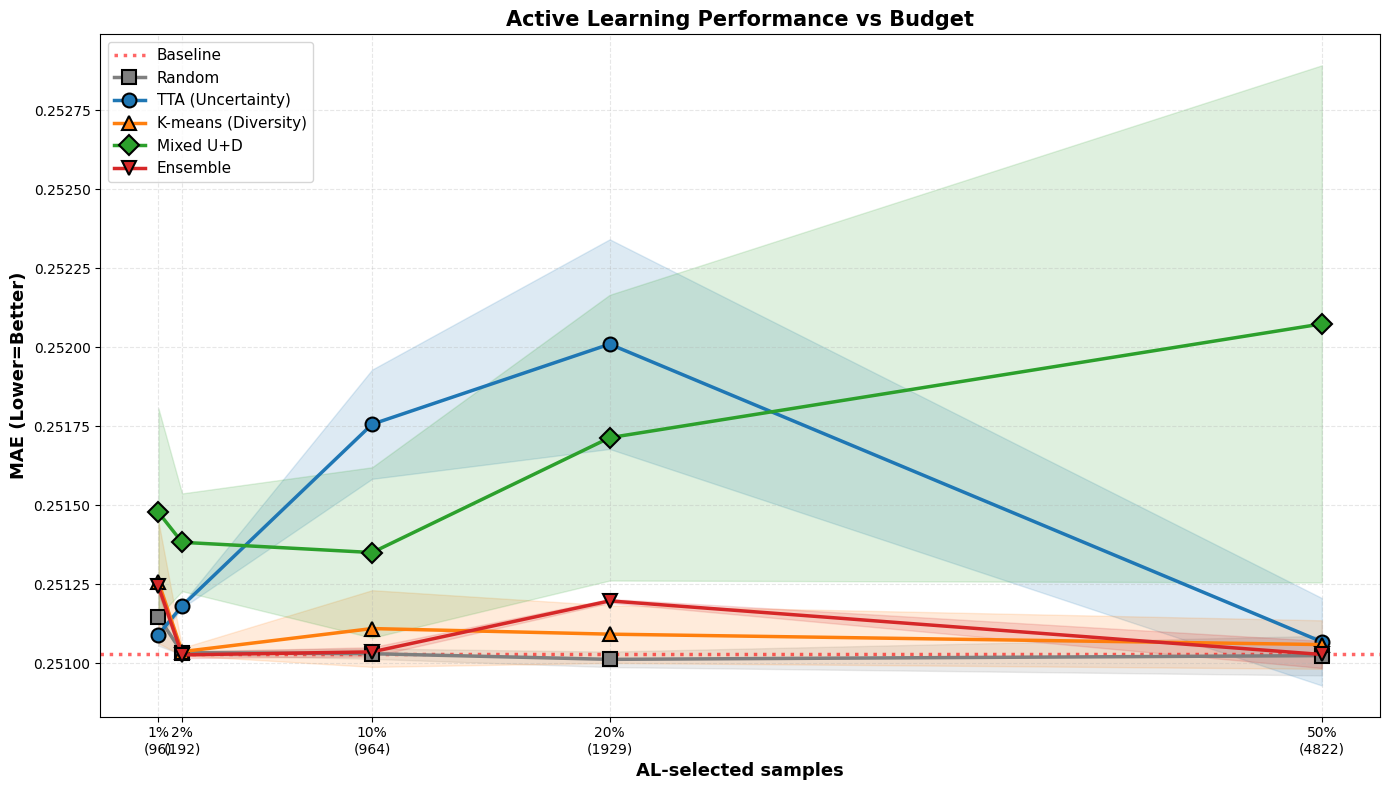

✓ Plot saved


In [31]:
# Plots
fig, ax = plt.subplots(figsize=(14, 8))

colors = {'random': '#7f7f7f', 'uncertainty_tta': '#1f77b4', 'diversity_kmeans': '#ff7f0e',
          'mixed_ud': '#2ca02c', 'ensemble': '#d62728'}
markers = {'random': 's', 'uncertainty_tta': 'o', 'diversity_kmeans': '^',
           'mixed_ud': 'D', 'ensemble': 'v'}
labels = {'random': 'Random', 'uncertainty_tta': 'TTA (Uncertainty)',
          'diversity_kmeans': 'K-means (Diversity)', 'mixed_ud': 'Mixed U+D',
          'ensemble': 'Ensemble'}

ax.axhline(baseline_metrics['mae'], color='red', linestyle=':', linewidth=2.5, alpha=0.6, label='Baseline')

for st in strategies:
    m = [np.mean(results[st][b]) for b in budgets]
    s = [np.std(results[st][b]) for b in budgets]
    ci = [1.96*ss/np.sqrt(n_runs) for ss in s]
    
    ax.plot(budgets, m, marker=markers[st], color=colors[st], linewidth=2.5, markersize=10,
            label=labels[st], markeredgewidth=1.5, markeredgecolor='black')
    ax.fill_between(budgets, [m[i]-ci[i] for i in range(len(budgets))],
                    [m[i]+ci[i] for i in range(len(budgets))], alpha=0.15, color=colors[st])

ax.set_xlabel('AL-selected samples', fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (Lower=Better)', fontsize=13, fontweight='bold')
ax.set_title('Active Learning Performance vs Budget', fontsize=15, fontweight='bold')
ax.set_xticks(budgets)
ax.set_xticklabels([f"{p}%\n({b})" for p,b in zip(budgets_pct, budgets)])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(active_learning_dir, 'al_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved")